<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_12_Practice_(Module_12_was_mandatory_concpetual_class).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

# Problem 1
# Dataset: kaggle.com/datasets/yasserh/housing-prices-dataset    1. Basic EDA & Feature Engineering

1. Load Housing.csv. Print .shape, .dtypes, .isnull().sum(), and .describe().
2. Plot a histogram of price. Is it skewed?
3. Compute .corr() on numeric columns. Which feature correlates most with price?
4. Plot a boxplot of price grouped by stories.

Shape: (545, 13)

Dtypes: 
 price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Isnull: 
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Describe: 
               price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.86

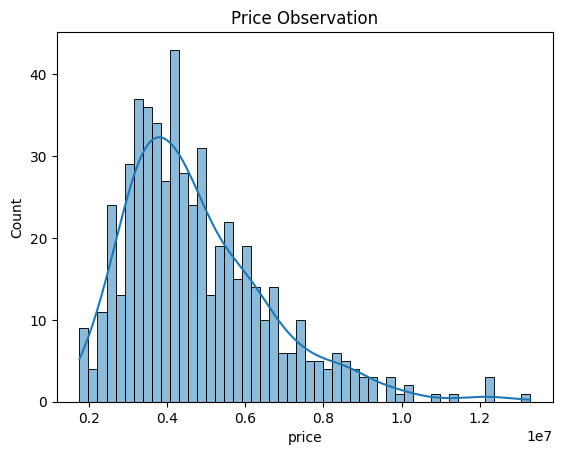

Most correlated feature: area


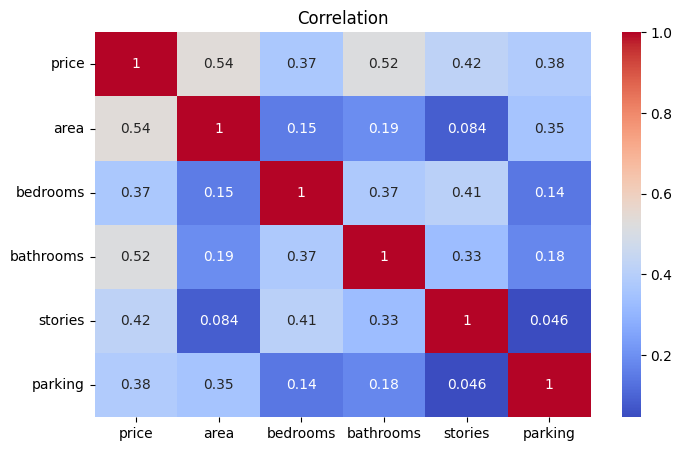

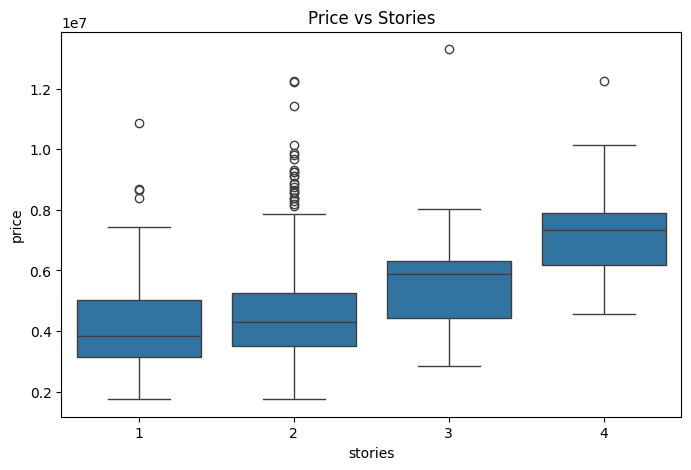

In [ ]:
# Load Housing.csv. Print .shape, .dtypes, .isnull().sum(), and .describe().
df_housing = pd.read_csv('Housing.csv')
print('Shape:', df_housing.shape)
print()
print('Dtypes: \n', df_housing.dtypes)
print()
print('Isnull: \n', df_housing.isnull().sum())
print()
print('Describe: \n', df_housing.describe())

# Plot a histogram of price. Is it skewed?
sns.histplot(data = df_housing, x = 'price', bins = 50, kde = True)
plt.title('Price Observation')
plt.show()
# Ans: Yes it's positively skewed.

# Compute .corr() on numeric columns. Which feature correlates most with price?
plt.figure(figsize = (8, 5))

corr_matrix = df_housing.select_dtypes(include = np.number).corr()
corr_with_price = corr_matrix['price'].drop('price').sort_values(ascending=False)
print("Most correlated feature:", corr_with_price.idxmax())

sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')
plt.title('Correlation')
plt.show()
# Ans: Area correlates most with the price

# Plot a boxplot of price grouped by stories.
plt.figure(figsize = (8, 5))
sns.boxplot(data = df_housing, x = 'stories', y = 'price')
plt.title('Price vs Stories')
plt.show()

# Problem 2

# Feature Engineering via Pipeline & ColumnTransformer

1. Split data: X = all features, y = price. Use train_test_split.
2. List your numeric columns in a variable called numeric_features.
3. Build a numeric_pipeline: steps = [SimpleImputer(median), StandardScaler()].
4. Wrap it in ColumnTransformer(transformers=[('num', numeric_pipeline, numeric_features)]).
5. Call preprocessor.fit_transform(X_train) and .transform(X_test). Print the output shape.

In [18]:
# Split data: X = all features, y = price. Use train_test_split.
X = df_housing.drop(columns = ['price'])
y = df_housing['price']

# List your numeric columns in a variable called numeric_features.
numeric_features = X.select_dtypes(include = ['int64', 'float64']).columns
categorical_features = X.select_dtypes(include = ['object']).columns

# Build a numeric_pipeline: steps = [SimpleImputer(median), StandardScaler()].
num_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
    ]
)

# Wrap it in ColumnTransformer(transformers=[('num', numeric_pipeline, numeric_features)]).
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features)
    ]
)

# Call preprocessor.fit_transform(X_train) and .transform(X_test). Print the output shape.
X_train, X_test , y_train, y_test = train_test_split(
    X,y, test_size = 0.20 , random_state = 42
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print('Shapes: \n', X_train_transformed.shape, X_test_transformed.shape)

Shapes: 
 (436, 5) (109, 5)


# Problem 3

# Train LinearRegression & SGDRegressor (using Pipeline)

1. Build lr_pipeline = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())]).
2. Fit lr_pipeline on X_train, y_train. Print .coef_ and .intercept_.
3. Build sgd_pipeline the same way but use SGDRegressor(random_state=42).
4. Fit sgd_pipeline on X_train, y_train. Print .coef_ and .intercept_.
5. Generate predictions for both models on X_train and X_test.

In [22]:
# Build lr_pipeline = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())]).
lr_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# Fit lr_pipeline on X_train, y_train. Print .coef_ and .intercept_.
train_fit_lin = lr_pipeline.fit(X_train, y_train)
train_weight_lin = lr_pipeline.named_steps['model'].coef_
train_bias_lin = lr_pipeline.named_steps['model'].intercept_

# Build sgd_pipeline the same way but use SGDRegressor(random_state=42).
ETA = 0.001
MAX_ITER = 3000
ALPHA = 0.0001

sgd_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', SGDRegressor(
            random_state = 42,
            eta0 = ETA,
            alpha = ALPHA,
            loss = 'squared_error',
            penalty = 'l2',
            learning_rate = 'constant',
            max_iter = MAX_ITER
            ))
    ]
)

# Fit sgd_pipeline on X_train, y_train. Print .coef_ and .intercept_.
train_fit_sgd = sgd_pipeline.fit(X_train, y_train)
train_weight_sgd = sgd_pipeline.named_steps['model'].coef_
train_bias_sgd = sgd_pipeline.named_steps['model'].intercept_

# Generate predictions for both models on X_train and X_test.
lr_pred_train = lr_pipeline.predict(X_train)
lr_pred_test = lr_pipeline.predict(X_test)

sgd_pred_train = sgd_pipeline.predict(X_train)
sgd_pred_test = sgd_pipeline.predict(X_test)

# Problem 4

# Evaluation Metrics — RMSE, MAE, R²

1. Compute RMSE, MAE, R² for LinearRegression on both train and test sets.
2. Compute the same metrics for SGDRegressor.
3. Print all results in one table using a pandas DataFrame.

In [24]:
# Compute RMSE, MAE, R² for LinearRegression on both train and test sets.
def evaluate(model, name):
  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)

  train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
  test_rmse  = np.sqrt(mean_squared_error(y_test, test_pred))
  train_mae  = mean_absolute_error(y_train, train_pred)
  test_mae   = mean_absolute_error(y_test, test_pred)
  train_r2   = r2_score(y_train, train_pred)
  test_r2    = r2_score(y_test, test_pred)


  return {
      'Model'      : name,
      'Train RMSE' : round(train_rmse, 2),
      'Test RMSE'  : round(test_rmse, 2),
      'Train MAE'  : round(train_mae, 2),
      'Test MAE'   : round(test_mae, 2),
      'Train R2'   : round(train_r2, 4),
      'Test R2'    : round(test_r2, 4)
  }

lr_results  = evaluate(lr_pipeline, 'Linear Regression')


# Compute the same metrics for SGDRegressor.
sgd_results = evaluate(sgd_pipeline, 'SGD Regressor')

# Print all results in one table using a pandas DataFrame.
result_df = pd.DataFrame([lr_results, sgd_results])
result_df = result_df.set_index('Model')
print(result_df)

                   Train RMSE   Test RMSE  Train MAE    Test MAE  Train R2  \
Model                                                                        
Linear Regression  1161898.54  1514173.55  853544.16  1127483.35    0.5622   
SGD Regressor      1161950.26  1516719.46  852981.03  1128789.49    0.5621   

                   Test R2  
Model                       
Linear Regression   0.5464  
SGD Regressor       0.5449  


# Problem 5

# Compare Both Models

1. Which model has lower Test RMSE — LinearRegression or SGDRegressor?
2. Is Train R² much higher than Test R²?


If yes, the model may be overfitting. Learn about Overfitting and Underfitting


In [31]:
# Which model has lower Test RMSE — LinearRegression or SGDRegressor?
if lr_results['Test RMSE'] > sgd_results['Test RMSE']:
    print('SGD Regressor has lower Test RMSE → better model')
else:
    print('Linear Regression has lower Test RMSE → better model')

# Is Train R² much higher than Test R²?
gap_lr  = lr_results['Train R2'] - lr_results['Test R2']
gap_sgd = sgd_results['Train R2'] - sgd_results['Test R2']

print(f"LR  R² gap: {round(gap_lr, 4)}")
print(f"SGD R² gap: {round(gap_sgd, 4)}")

# Apart from these tests, from the earlier observations we can see from the data table that the linear regression has lower test rmse than sgd regression and for the test for r2, it's not much higher.
# Which also proves that the linear regression model is better than sgd regression because it has lower rmse test and lower gap of r2 which means no overfitting.

Linear Regression has lower Test RMSE → better model
LR  R² gap: 0.0158
SGD R² gap: 0.0172
